# K-Means Baseline Experiment

#TODO METER NO RELATÓRIO
- `n_init=1` per call, loop controlled externally
- seed formula: `seed = 100 * K + run`
- M = 10 runs per (K, init_method) pair
- K values: 2–8
- Both `random` and `k-means++` initialisation
- PCA pre-processing before clustering (85% variance)
- Subsampling stability: 3 independent subsamples
- All results logged to `experiments.csv`

## Setup

In [3]:
import os
# Single-threaded libs for reproducible runtimes
os.environ["OMP_NUM_THREADS"]      = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"]      = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]  = "1"

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from sklearn.decomposition import PCA
from IPython.display import display

from src.preprocessing import preprocess_data, NUMERICAL_FEATURES
from src.clustering   import fit_kmeans_once, run_kmeans, fit_predict
from src.evaluation   import evaluate_clustering, metric_info
from src.utils        import load_subsample_indices, log_experiment

plt.rcParams["figure.dpi"]          = 120
plt.rcParams["axes.grid"]           = True
plt.rcParams["grid.alpha"]          = 0.25
plt.rcParams["axes.spines.top"]     = False
plt.rcParams["axes.spines.right"]   = False

# Colour palette from Lab4
slide_palette = [
    "#4C6FE7", "#E3B340", "#4FA64F", "#E45756",
    "#8E63C7", "#D99AD7", "#8C6D31", "#7F7F7F",
]

DATA_PATH       = "../data/hotel_bookings_course_release_v1.csv"
INDICES_PATH    = "../data/subsample_indices_v1_n30000_seed12345.txt"
EXPERIMENTS_CSV = "../experiments.csv"

## Load data and preprocess

In [4]:
df_full  = pd.read_csv(DATA_PATH)
indices  = load_subsample_indices(INDICES_PATH)
df       = df_full.iloc[indices].reset_index(drop=True)

REPRESENTATION_ID = "rep_full_std"

X, feature_names = preprocess_data(df, feature_set="no_value_block", scaler="standard")

n, d = X.shape

pca2 = PCA(n_components=2, random_state=0)
X_pca2 = pca2.fit_transform(X)

pca3 = PCA(n_components=3, random_state=0)
X_pca3 = pca3.fit_transform(X)


summary = pd.DataFrame({
    "quantity": ["n samples", "d features", "representation_id",
                 "candidate K values", "runs per K and method"],
    "value":    [n, d, REPRESENTATION_ID, "2, 3, 4, 5, 6, 7, 8", 10],
})
display(summary)

# PCA variance table (Lab4 style)
pca_check = PCA(n_components=3, random_state=0).fit(X)
pca_df = pd.DataFrame({
    "component":                pca_check.components_[:, 0] * 0 + [1, 2, 3], 
    "explained_variance_ratio": pca_check.explained_variance_ratio_.round(3),
    "cumulative_ratio":         np.cumsum(pca_check.explained_variance_ratio_).round(3),
})
pca_df["component"] = ["PC1", "PC2", "PC3"]
print("PCA variance (visualisation only):")
display(pca_df)

,quantity,value
0,n samples,30000
1,d features,35
2,representation_id,rep_full_std
3,candidate K values,"2, 3, 4, 5, 6, 7, 8"
4,runs per K and method,10


PCA variance (visualisation only):


,component,explained_variance_ratio,cumulative_ratio
0,PC1,0.136,0.136
1,PC2,0.124,0.261
2,PC3,0.100,0.361


## Plotting helpers

In [5]:
#2D PCA scatter coloured by cluster
def plot_partition_2d(ax, coords, labels, centers, title):
    
    K = len(np.unique(labels))
    for k in range(K):
        mask = labels == k
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=34, c=slide_palette[k % len(slide_palette)],
                   alpha=0.85, edgecolor="white", linewidth=0.4)
    centers_2d = pca2.transform(centers)
    ax.scatter(centers_2d[:, 0], centers_2d[:, 1],
               c="black", s=110, marker="X", linewidth=0.8, zorder=5)
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

#3D PCA scatter coloured by cluster
def plot_partition_3d(ax, coords, labels, centers, title):
    K = len(np.unique(labels))
    for k in range(K):
        mask = labels == k
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   s=28, c=slide_palette[k % len(slide_palette)],
                   alpha=0.85, depthshade=False)
    centers_3d = pca3.transform(centers)
    ax.scatter(centers_3d[:, 0], centers_3d[:, 1], centers_3d[:, 2],
               c="black", s=120, marker="X", depthshade=False)
    ax.set_title(title)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
    ax.view_init(elev=22, azim=-58)

## Quick visual — k-means++ for K ∈ {2, 3, 4, 5,6 ,7 ,8 ,9}

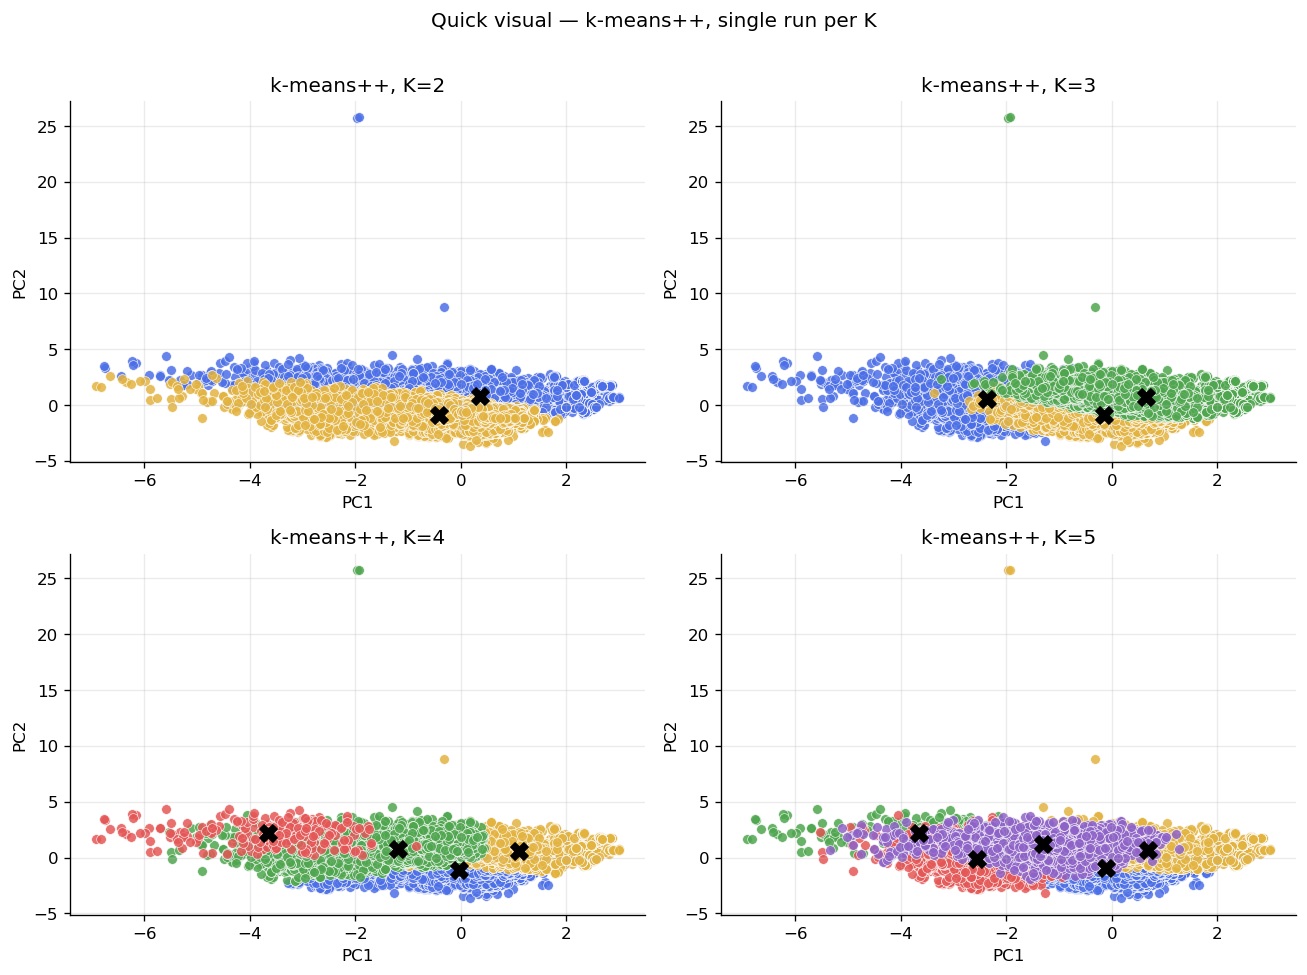

In [6]:
K_demo    = [2, 3, 4, 5, 6, 7, 8, 9]
seed_demo = 7

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, K in zip(axes.ravel(), K_demo):
    _, labels_demo, centers_demo = fit_kmeans_once(X, K, init_method="k-means++", seed=seed_demo + K)
    plot_partition_2d(ax, X_pca2, labels_demo, centers_demo, title=f"k-means++, K={K}")
plt.suptitle("Quick visual — k-means++, single run per K", y=1.01)
plt.tight_layout()
plt.show()

## Experimental protocol, K-Means


In [8]:
#For each (K, init_method): M = 10 runs with `seed = 100 × K + run`. All runs logged to `experiments.csv`.

K_VALUES     = list(range(2, 9))   
M            = 10     #Minimum 10
INIT_METHODS = ["random", "k-means++"]

all_rows = []

for init_method in INIT_METHODS:
    for K in K_VALUES:
        for run in range(1, M + 1):
            seed = 100 * K + run   # Lab4 seed formula

            labels, model, runtime = fit_predict(
                X, K, seed=seed, algorithm="kmeans"
            )
            metrics = evaluate_clustering(X, labels, runtime=runtime)

            row = {
                "representation_id": REPRESENTATION_ID,
                "method":            "kmeans",
                "init":              init_method,
                "K":                 K,
                "run":               run,
                "seed":              seed,
                "sample_rule":       f"subsample_n{n}_seed12345",
                "inertia":           model.inertia_,
                "n_iter":            model.n_iter_,
                **metrics,
            }
            all_rows.append(row)
            log_experiment(row, filepath=EXPERIMENTS_CSV)

all_runs = pd.DataFrame(all_rows)
print(f"Total runs logged: {len(all_runs)}")
display(all_runs.head(6))

Total runs logged: 140


,representation_id,method,init,K,run,seed,sample_rule,inertia,n_iter,silhouette,calinski_harabasz,davies_bouldin,runtime_s
0,rep_full_std,kmeans,random,2,1,201,subsample_n30000_seed12345,303526.980294,11,0.151569,3278.167047,2.769580,0.047650
1,rep_full_std,kmeans,random,2,2,202,subsample_n30000_seed12345,303914.280965,4,0.325460,3235.760741,1.432237,0.028570
2,rep_full_std,kmeans,random,2,3,203,subsample_n30000_seed12345,308292.234246,46,0.091158,2763.855991,3.005354,0.098805
3,rep_full_std,kmeans,random,2,4,204,subsample_n30000_seed12345,308292.884838,24,0.090916,2763.794007,3.003853,0.060637
4,rep_full_std,kmeans,random,2,5,205,subsample_n30000_seed12345,303526.980294,24,0.151569,3278.167047,2.769580,0.060615
5,rep_full_std,kmeans,random,2,6,206,subsample_n30000_seed12345,308028.011754,46,0.103177,2792.082176,3.022851,0.100707


## Score variability across runs

In [9]:
#Mean and std of each metric per (init, K)
score_variability = (
    all_runs
    .groupby(["init", "K"])[["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]]
    .agg(["mean", "std"])
    .round(4)
)
display(score_variability)

silhouette         calinski_harabasz           davies_bouldin  \
                  mean     std              mean       std           mean   
init      K                                                                 
k-means++ 2     0.1609  0.0805         2989.7438  243.7015         2.6474   
          3     0.1006  0.0056         3003.4117  154.4989         2.4234   
          4     0.1060  0.0117         2996.7737  210.7474         2.2270   
          5     0.1175  0.0126         3226.4035  370.3883         1.9662   
          6     0.1209  0.0087         3182.5616  165.3602         1.8876   
          7     0.1319  0.0147         3555.0518  315.9988         1.7084   
          8     0.1337  0.0110         3317.6895  487.5550         1.7138   
random    2     0.1609  0.0805         2989.7438  243.7015         2.6474   
          3     0.1006  0.0056         3003.4117  154.4989         2.4234   
          4     0.1060  0.0117         2996.7737  210.7474         2.2270   
          5     0.1175  0.0126         3226.4035  370.3883         1.9662   
          6     0.1209  0.0087         3182.5616  165.3602         1.8876   
          7     0.1319  0.0147         3555.0518  315.9988         1.7084   
          8     0.1337  0.0110         3317.6895  487.5550         1.7138   

                         inertia              
                std         mean         std  
init      K                                   
k-means++ 2  0.5814  306196.0702   2257.3181  
          3  0.1727  280541.1444   2408.5760  
          4  0.1076  259115.2184   4222.8608  
          5  0.1434  235662.8698   8156.5579  
          6  0.0737  220050.4053   3949.8045  
          7  0.0905  197014.0970   7550.0500  
          8  0.1663  190497.6625  12804.9140  
random    2  0.5814  306196.0702   2257.3181  
          3  0.1727  280541.1444   2408.5760  
          4  0.1076  259115.2184   4222.8608  
          5  0.1434  235662.8698   8156.5579  
          6  0.0737  220050.4053   3949.8045  
          7  0.0905  197014.0970   7550.0500  
          8  0.1663  190497.6625  12804.9140

## Best run per K and metric curves

In [11]:
#Return the best-scoring run at each K for the given metric.
def best_run_per_K(df_runs, metric_name):
   
    direction = metric_info[metric_name]["direction"]
    idx = (df_runs.groupby("K")[metric_name].idxmax()
           if direction == "max"
           else df_runs.groupby("K")[metric_name].idxmin())
    return df_runs.loc[idx].sort_values("K").reset_index(drop=True)


curve_rows      = []
best_partitions = {}
summary_rows    = []

for init_method in INIT_METHODS:
    subset = all_runs[all_runs["init"] == init_method].copy()
    for metric_name, info in metric_info.items():
        best_k_table = best_run_per_K(subset, metric_name)

        for _, row in best_k_table.iterrows():
            curve_rows.append({
                "init": init_method, "metric": metric_name,
                "K": int(row["K"]), "best_score": float(row[metric_name]),
            })

        best_row = (best_k_table.loc[best_k_table[metric_name].idxmax()]
                    if info["direction"] == "max"
                    else best_k_table.loc[best_k_table[metric_name].idxmin()])
        best_partitions[(init_method, metric_name)] = best_row
        summary_rows.append({
            "init": init_method, "metric": info["label"],
            "direction": info["direction"],
            "K_best": int(best_row["K"]),
            "best_score": float(best_row[metric_name]),
            "seed": int(best_row["seed"]),
        })

curve_df     = pd.DataFrame(curve_rows)
best_summary = pd.DataFrame(summary_rows)
display(best_summary.round(4))

,init,metric,direction,K_best,best_score,seed
0,random,Silhouette,max,2,0.3255,202
1,random,Calinski–Harabasz,max,5,3769.1808,510
2,random,Davies–Bouldin,min,2,1.4322,202
3,k-means++,Silhouette,max,2,0.3255,202
4,k-means++,Calinski–Harabasz,max,5,3769.1808,510
5,k-means++,Davies–Bouldin,min,2,1.4322,202


## Metric curves — Silhouette, Calinski–Harabasz, Davies–Bouldin

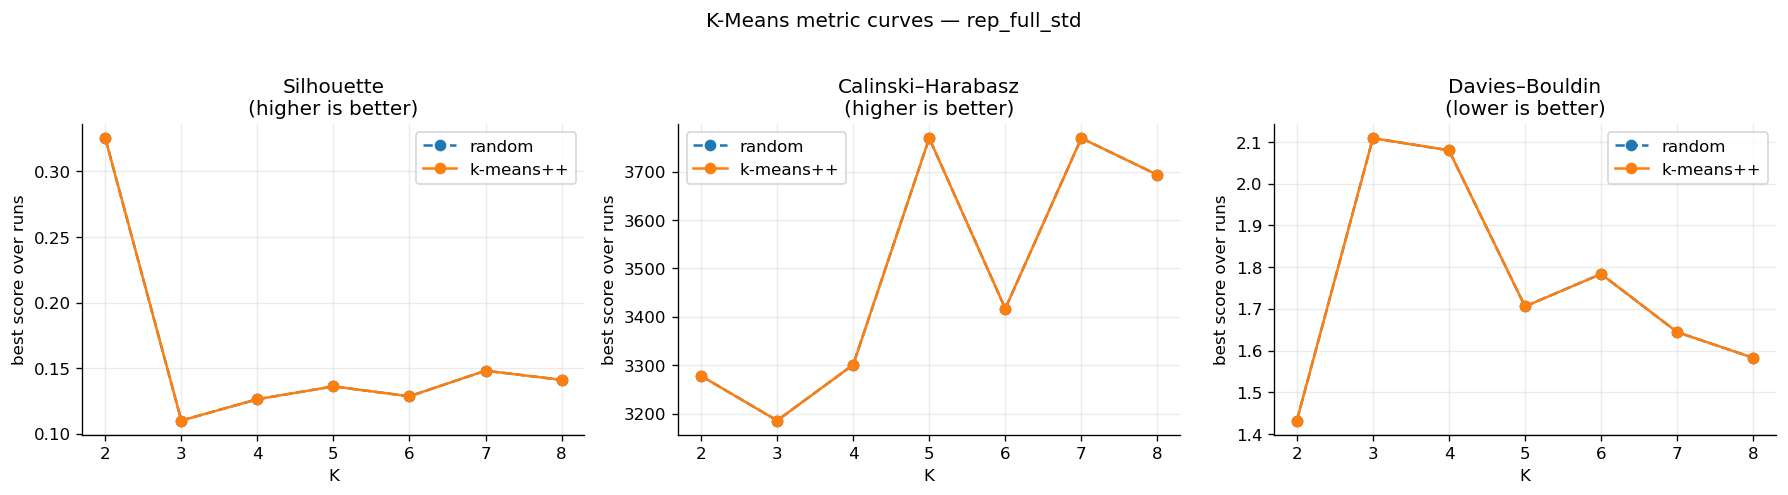

In [12]:
#Best score per K for each metric and initialisation method 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric_name in zip(axes, metric_info):
    info = metric_info[metric_name]
    for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
        sub = curve_df[
            (curve_df["init"] == init_method) & (curve_df["metric"] == metric_name)
        ]
        ax.plot(sub["K"], sub["best_score"], marker="o", linestyle=line_style, label=init_method)
    better = "higher is better" if info["direction"] == "max" else "lower is better"
    ax.set_title(f"{info['label']}\n({better})")
    ax.set_xlabel("K")
    ax.set_xticks(K_VALUES)
    ax.set_ylabel("best score over runs")
    ax.legend(frameon=True)

plt.suptitle(f"K-Means metric curves — {REPRESENTATION_ID}", y=1.02)
plt.tight_layout()
plt.show()

## Elbow Curve

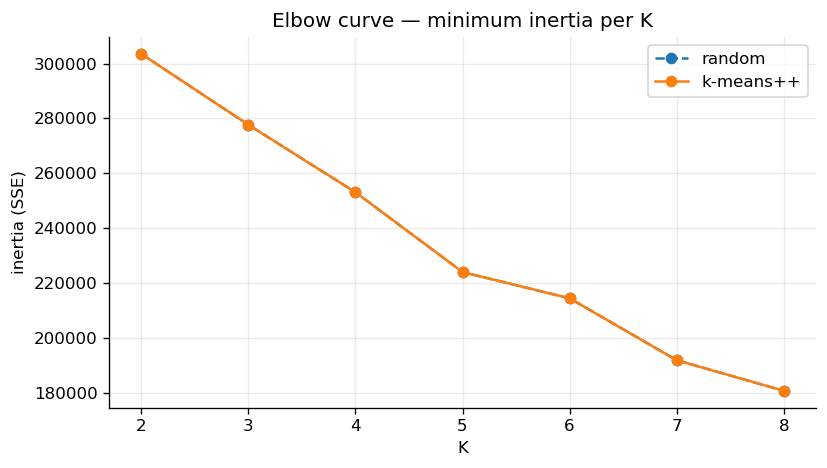

In [13]:
#Plot the elbow curve.
fig, ax = plt.subplots(figsize=(7, 4))
for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
    sub = all_runs[all_runs["init"] == init_method].groupby("K")["inertia"].min()
    ax.plot(sub.index, sub.values, marker="o", linestyle=line_style, label=init_method)
ax.set_title("Elbow curve — minimum inertia per K")
ax.set_xlabel("K")
ax.set_xticks(K_VALUES)
ax.set_ylabel("inertia (SSE)")
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 10. Best partitions — 2D PCA visualisation and 3D PCA visualisation

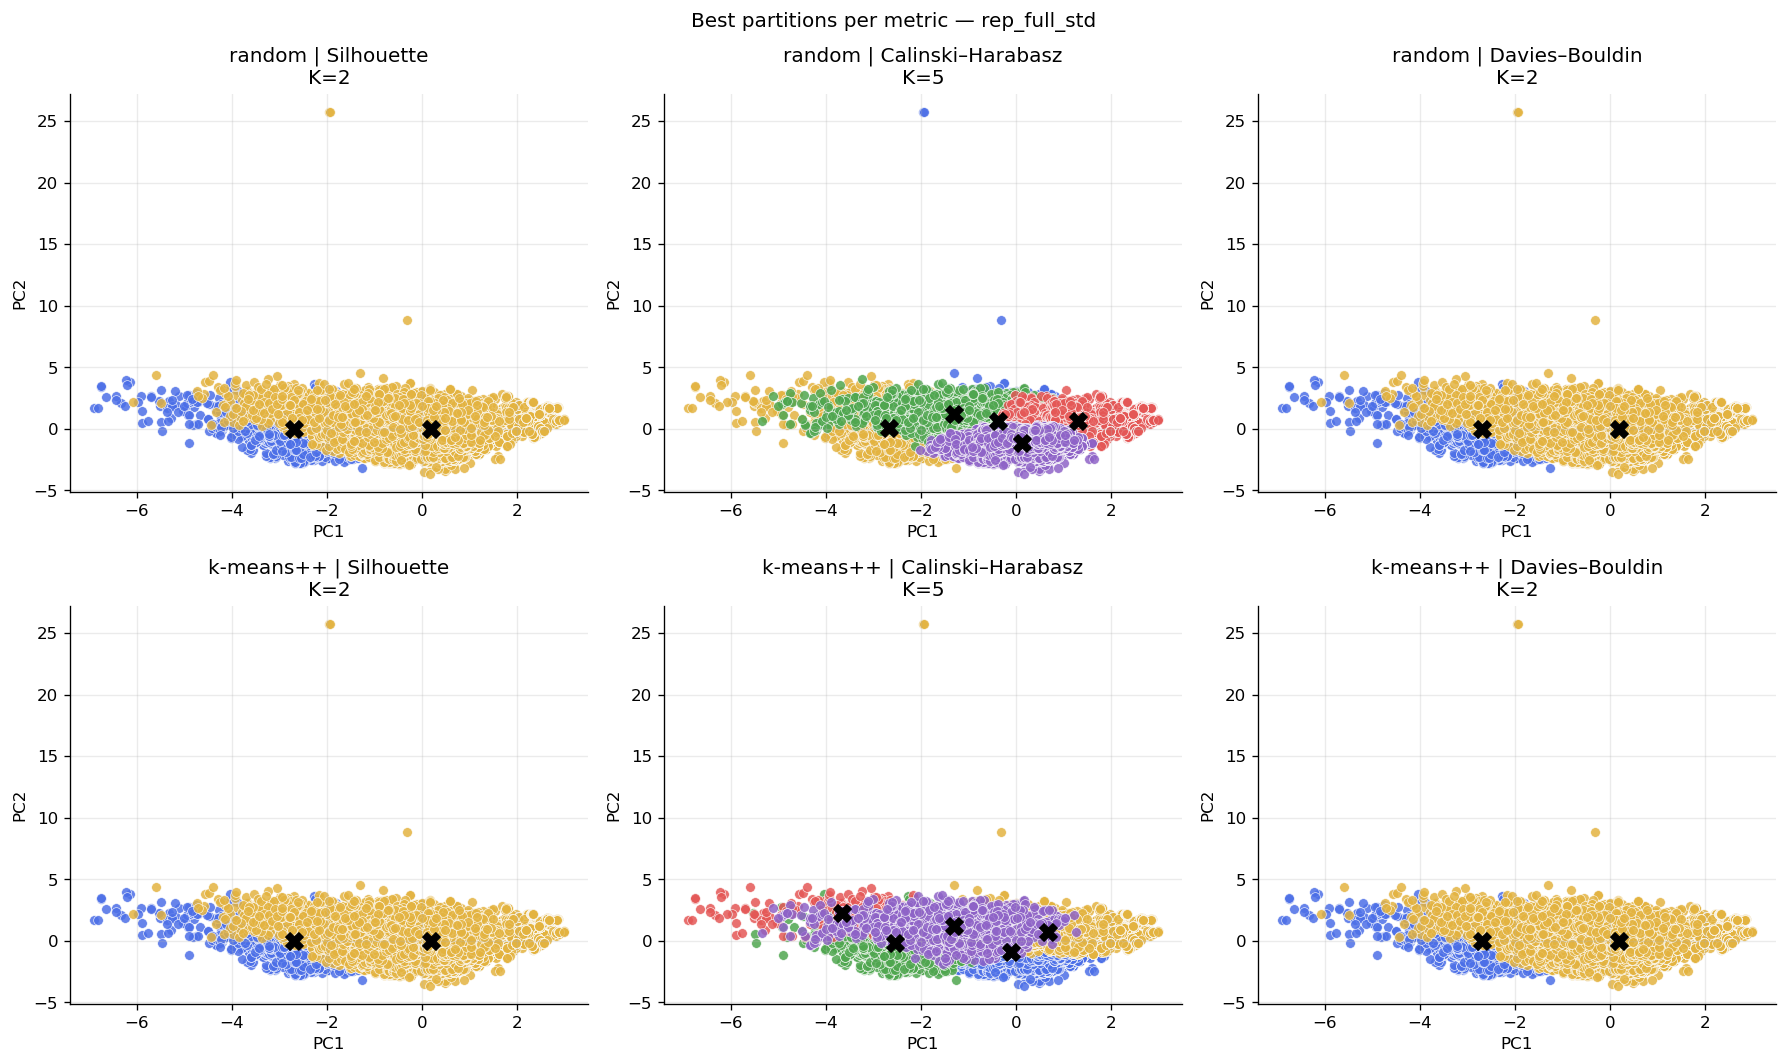

In [14]:
#Best partition per (init, metric) shown in PCA space 2D

metric_order  = list(metric_info.keys())
metric_titles = {k: v["label"] for k, v in metric_info.items()}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i, init_method in enumerate(INIT_METHODS):
    for j, metric_name in enumerate(metric_order):
        best_row  = best_partitions[(init_method, metric_name)]
        K_best    = int(best_row["K"])
        seed_best = int(best_row["seed"])
        _, labels_plot, centers_plot = fit_kmeans_once(
            X, K_best, init_method=init_method, seed=seed_best
        )
        plot_partition_2d(
            axes[i, j], X_pca2, labels_plot, centers_plot,
            title=f"{init_method} | {metric_titles[metric_name]}\nK={K_best}",
        )
plt.suptitle(f"Best partitions per metric — {REPRESENTATION_ID}")
plt.tight_layout()
plt.show()

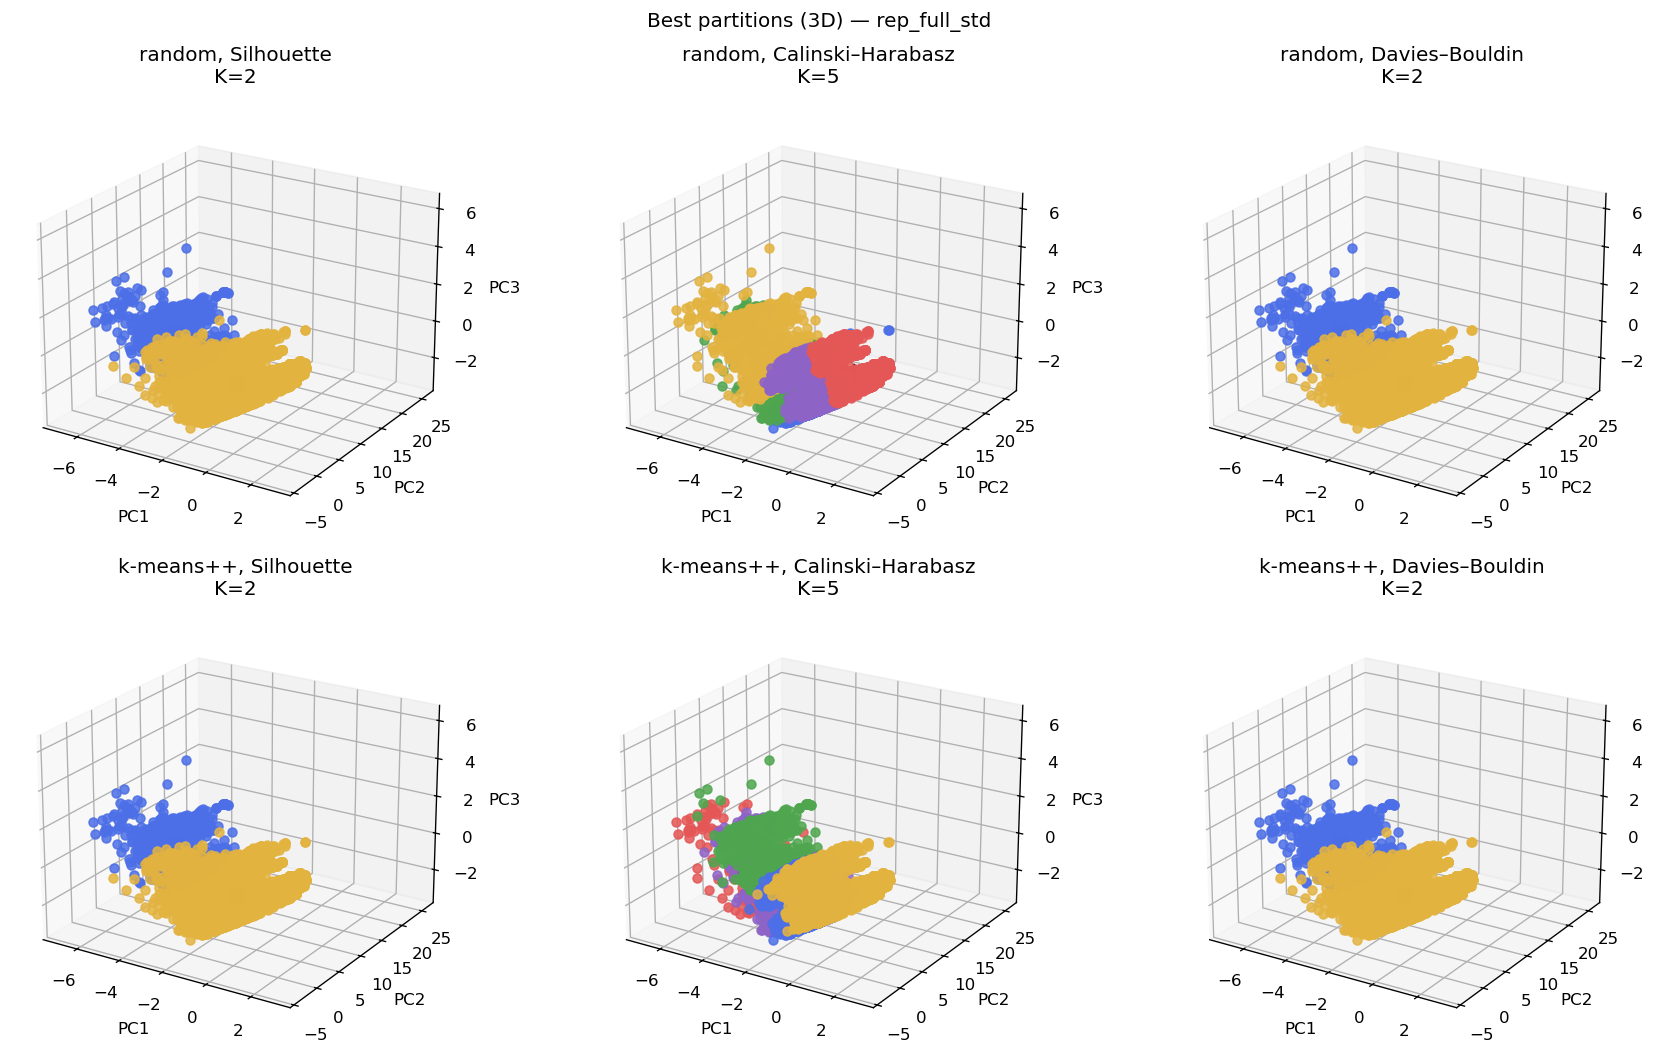

In [15]:
#Best partition per (init, metric) shown in PCA space 3D

fig = plt.figure(figsize=(15, 9))
for index, (init_method, metric_name) in enumerate(
    [(m, t) for m in INIT_METHODS for t in metric_order], start=1
):
    best_row  = best_partitions[(init_method, metric_name)]
    K_best    = int(best_row["K"])
    seed_best = int(best_row["seed"])
    _, labels_plot, centers_plot = fit_kmeans_once(
        X, K_best, init_method=init_method, seed=seed_best
    )
    ax = fig.add_subplot(2, 3, index, projection="3d")
    plot_partition_3d(
        ax, X_pca3, labels_plot, centers_plot,
        title=f"{init_method}, {metric_titles[metric_name]}\nK={K_best}",
    )
plt.suptitle(f"Best partitions (3D) — {REPRESENTATION_ID}")
plt.tight_layout()
plt.show()

## Convergence, number of iterations per (init, K)

,init,K,mean_iterations,median_iterations,std_iterations,min_iterations,max_iterations
0,k-means++,2,20.8,20.5,15.35,4,46
1,k-means++,3,22.1,22.0,8.72,12,41
2,k-means++,4,29.7,26.0,14.51,14,56
3,k-means++,5,36.3,30.5,19.98,11,79
4,k-means++,6,23.5,20.5,11.94,13,53
5,k-means++,7,29.1,29.0,5.53,23,42
6,k-means++,8,29.5,25.0,14.40,13,54
7,random,2,20.8,20.5,15.35,4,46
8,random,3,22.1,22.0,8.72,12,41
9,random,4,29.7,26.0,14.51,14,56


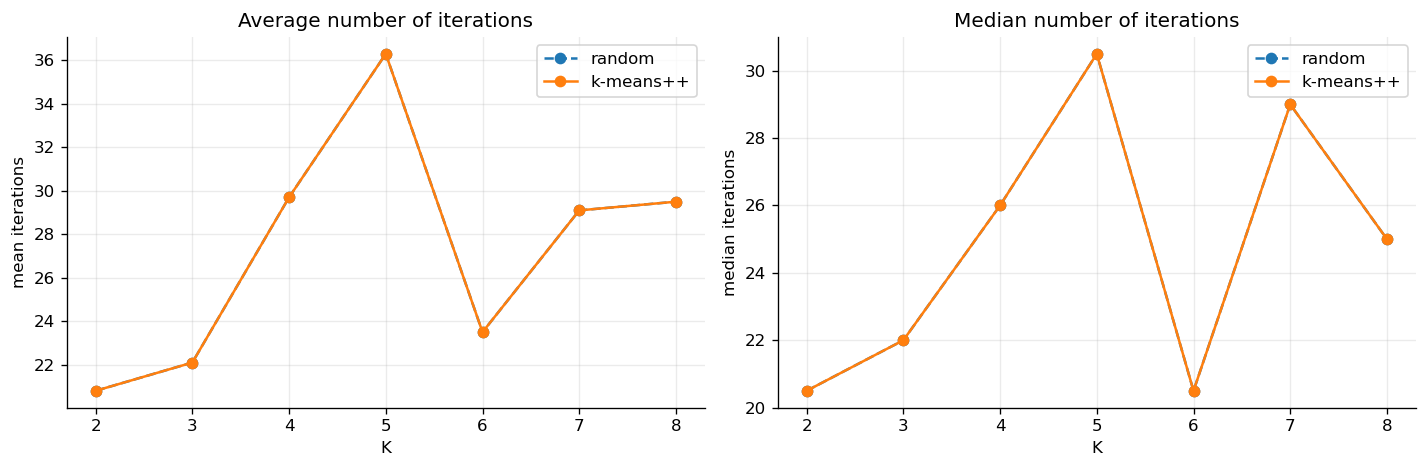

In [16]:
#Checks convergence speed of `random` vs `k-means++`.

conv_summary = (
    all_runs
    .groupby(["init", "K"])
    .agg(
        mean_iterations  =("n_iter", "mean"),
        median_iterations=("n_iter", "median"),
        std_iterations   =("n_iter", "std"),
        min_iterations   =("n_iter", "min"),
        max_iterations   =("n_iter", "max"),
    )
    .reset_index()
)
display(conv_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, stat_name, title in [
    (axes[0], "mean_iterations",   "Average number of iterations"),
    (axes[1], "median_iterations", "Median number of iterations"),
]:
    for init_method, line_style in [("random", "--"), ("k-means++", "-")]:
        sub = conv_summary[conv_summary["init"] == init_method]
        ax.plot(sub["K"], sub[stat_name], marker="o", linestyle=line_style, label=init_method)
    ax.set_title(title)
    ax.set_xlabel("K")
    ax.set_ylabel(stat_name.replace("_", " "))
    ax.set_xticks(K_VALUES)
    ax.legend(frameon=True)
plt.tight_layout()
plt.show()

## 13. Runtime summary

In [17]:
#Mean / min / max wall-clock time per (init, K) in seconds.
runtime_summary = (
    all_runs
    .groupby(["init", "K"])["runtime_s"]
    .agg(["mean", "min", "max"])
    .round(3)
)
display(runtime_summary)

mean    min    max
init      K                     
k-means++ 2  0.052  0.021  0.093
          3  0.056  0.041  0.087
          4  0.071  0.042  0.120
          5  0.092  0.043  0.172
          6  0.068  0.048  0.126
          7  0.088  0.070  0.112
          8  0.086  0.052  0.134
random    2  0.056  0.024  0.101
          3  0.063  0.039  0.125
          4  0.075  0.041  0.128
          5  0.095  0.043  0.167
          6  0.073  0.048  0.138
          7  0.089  0.072  0.117
          8  0.092  0.054  0.144

## Cluster profile — best partition by silhouette

In [18]:
#Profile computed on the original (unscaled) values for interpretability. A GLOBAL row is appended as reference.
def show_profile(K_target, init_method, metric_name):
    """Print mean cluster profile for the best partition at K_target."""
    best_k_table = best_run_per_K(
        all_runs[all_runs["init"] == init_method], metric_name
    )
    row       = best_k_table[best_k_table["K"] == K_target].iloc[0]
    seed_best = int(row["seed"])

    _, labels, _ = fit_kmeans_once(X, K_target, init_method=init_method, seed=seed_best)

    num_cols   = [c for c in NUMERICAL_FEATURES if c in df.columns]
    profile_df = df[num_cols].copy()
    profile_df["cluster"] = labels

    profile = profile_df.groupby("cluster")[num_cols].mean().round(2)
    profile.loc["GLOBAL"] = df[num_cols].mean().round(2)
    sizes = pd.Series(labels).value_counts().sort_index().rename("n")

    print(f"\n{'='*60}")
    print(f"Profile — {init_method}, K={K_target}, seed={seed_best} (best {metric_name})")
    print(f"{'='*60}")
    display(profile)
    print("Cluster sizes:")
    display(sizes)

In [19]:
# Show profiles for the two most relevant K values
best_sil_K = int(best_summary[
    (best_summary["init"] == "k-means++") & (best_summary["metric"] == "Silhouette")
]["K_best"].values[0])

best_db_K = int(best_summary[
    (best_summary["init"] == "k-means++") & (best_summary["metric"] == "Davies–Bouldin")
]["K_best"].values[0])

show_profile(best_sil_K, "k-means++", "silhouette")
if best_db_K != best_sil_K:
    show_profile(best_db_K, "k-means++", "davies_bouldin")


Profile — k-means++, K=2, seed=202 (best silhouette)


,lead_time,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,adr,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
cluster,,,,,,,,,,
0,53.92,1.89,0.19,0.02,0.03,0.50,113.47,0.83,1.00,0.08
1,107.16,1.85,0.10,0.01,0.10,0.11,101.04,0.55,0.00,0.03
GLOBAL,103.80,1.85,0.10,0.01,0.09,0.14,101.83,0.56,0.06,0.03


Cluster sizes:


0     1898
1    28102
Name: n, dtype: int64